In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from graphviz import Digraph


In [36]:
df = pd.read_csv("/kaggle/input/mushroom-classification/mushrooms.csv")
print(df.shape)
print(df.head())


(8124, 23)
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w 

In [37]:
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(df_encoded.head())


   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                         2   
4             1          0           4  ...                         2   

   stalk-color-above-ring  stalk-color-below-ring  veil-type  veil-color  \
0         

In [38]:
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

# Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Validation (15%) vs Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)


(5686, 22) (1219, 22) (1219, 22)


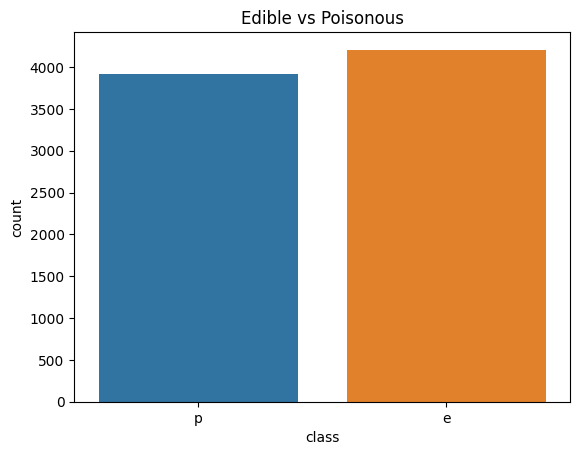

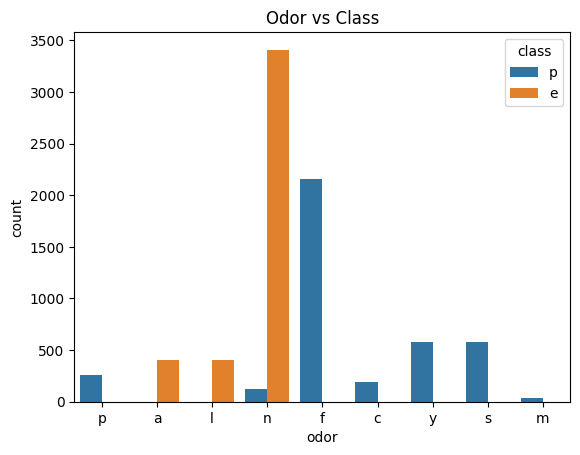

In [39]:
# Target balance
sns.countplot(x="class", data=df)
plt.title("Edible vs Poisonous")
plt.show()

# Example: odor distribution
sns.countplot(x="odor", hue="class", data=df)
plt.title("Odor vs Class")
plt.show()


# A.2 Decision Tree 

In [40]:
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def information_gain_binary(X_column, y, threshold):
    # Parent entropy
    parent_entropy = entropy(y)
    
    # Split into two groups
    left_mask = X_column <= threshold
    right_mask = X_column > threshold
    n = len(y)
    n_left = np.sum(left_mask)
    n_right = np.sum(right_mask)
    
    # Edge case: skip if no split
    if n_left == 0 or n_right == 0:
        return 0
    
    # Compute weighted entropy
    weighted_entropy = (
        (n_left / n) * entropy(y[left_mask]) +
        (n_right / n) * entropy(y[right_mask])
    )
    return parent_entropy - weighted_entropy

def best_split_binary(X, y):
    best_gain = -1
    best_feature = None
    best_threshold = None
    for feature in X.columns:
        X_column = X[feature]
        # Possible thresholds: midpoints between sorted unique values
        values = np.sort(np.unique(X_column))
        thresholds = (values[:-1] + values[1:]) / 2
        for threshold in thresholds:
            gain = information_gain_binary(X_column, y, threshold)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    return best_feature, best_threshold




In [41]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y, depth=0):
         # if pure node
        if len(np.unique(y)) == 1:
            return np.unique(y)[0]
        
        # stop conditions
        if (self.max_depth is not None and depth >= self.max_depth) or len(y) < self.min_samples_split:
            return y.mode()[0]  # majority vote

        # Find best feature and threshold for binary split
        best_feature, best_threshold = best_split_binary(X, y)
        if best_feature is None or best_threshold is None:
            return y.mode()[0]

        # Create children nodes for the binary split
        left_mask = X[best_feature] <= best_threshold
        right_mask = X[best_feature] > best_threshold
        
        subtree = {
            (best_feature, best_threshold): {
                'left': self.fit(X[left_mask], y[left_mask], depth + 1),
                'right': self.fit(X[right_mask], y[right_mask], depth + 1)
            }
        }
        self.tree = subtree
        return subtree

In [48]:
def predict_one(tree, x):
    if not isinstance(tree, dict):
        return label_decoder.get(tree, tree)
    # Only one key at this level: (feature, threshold)
    (feature, threshold), children = next(iter(tree.items()))
    value = x[feature]
    # Use <= for left, > for right (as in tree builder)
    if value <= threshold:
        return predict_one(children['left'], x)
    else:
        return predict_one(children['right'], x)


In [43]:
tree_model = DecisionTree(max_depth=10)
tree = tree_model.fit(X_train, y_train)

print(tree)


{('gill-color', 0.5): {'left': 1, 'right': {('spore-print-color', 1.5): {'left': {('odor', 3.5): {'left': 1, 'right': 0}}, 'right': {('gill-size', 0.5): {'left': {('spore-print-color', 4.5): {'left': 0, 'right': {('stalk-root', 0.5): {'left': 0, 'right': {('habitat', 3.5): {'left': {('stalk-surface-above-ring', 2.5): {'left': 1, 'right': 0}}, 'right': 0}}}}}}, 'right': {('odor', 5.5): {'left': {('odor', 2.0): {'left': {('bruises', 0.5): {'left': 1, 'right': 0}}, 'right': {('stalk-surface-below-ring', 2.5): {'left': {('population', 2.5): {'left': 1, 'right': 0}}, 'right': 1}}}}, 'right': 1}}}}}}}}


In [56]:
# Encode all columns
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
sample = df.iloc[2].to_dict()
prediction = predict_one(tree, sample)
print("Prediction:", prediction)


Prediction: edible


In [ ]:
def visualize_tree(tree, parent_name="Root", graph=None, edge_label=""):
    if graph is None:
        graph = Digraph()
        graph.node(parent_name, parent_name)

    if not isinstance(tree, dict):
        # Leaf node
        node_name = f"{tree}_{id(tree)}"
        graph.node(node_name, str(tree), shape="box", color="lightblue")
        graph.edge(parent_name, node_name, label=edge_label)
        return graph

    feature = next(iter(tree))
    for value, subtree in tree[feature].items():
        node_name = f"{feature}_{value}_{id(subtree)}"
        graph.node(node_name, f"{feature} = {value}")
        graph.edge(parent_name, node_name, label=edge_label)
        visualize_tree(subtree, node_name, graph)

    return graph


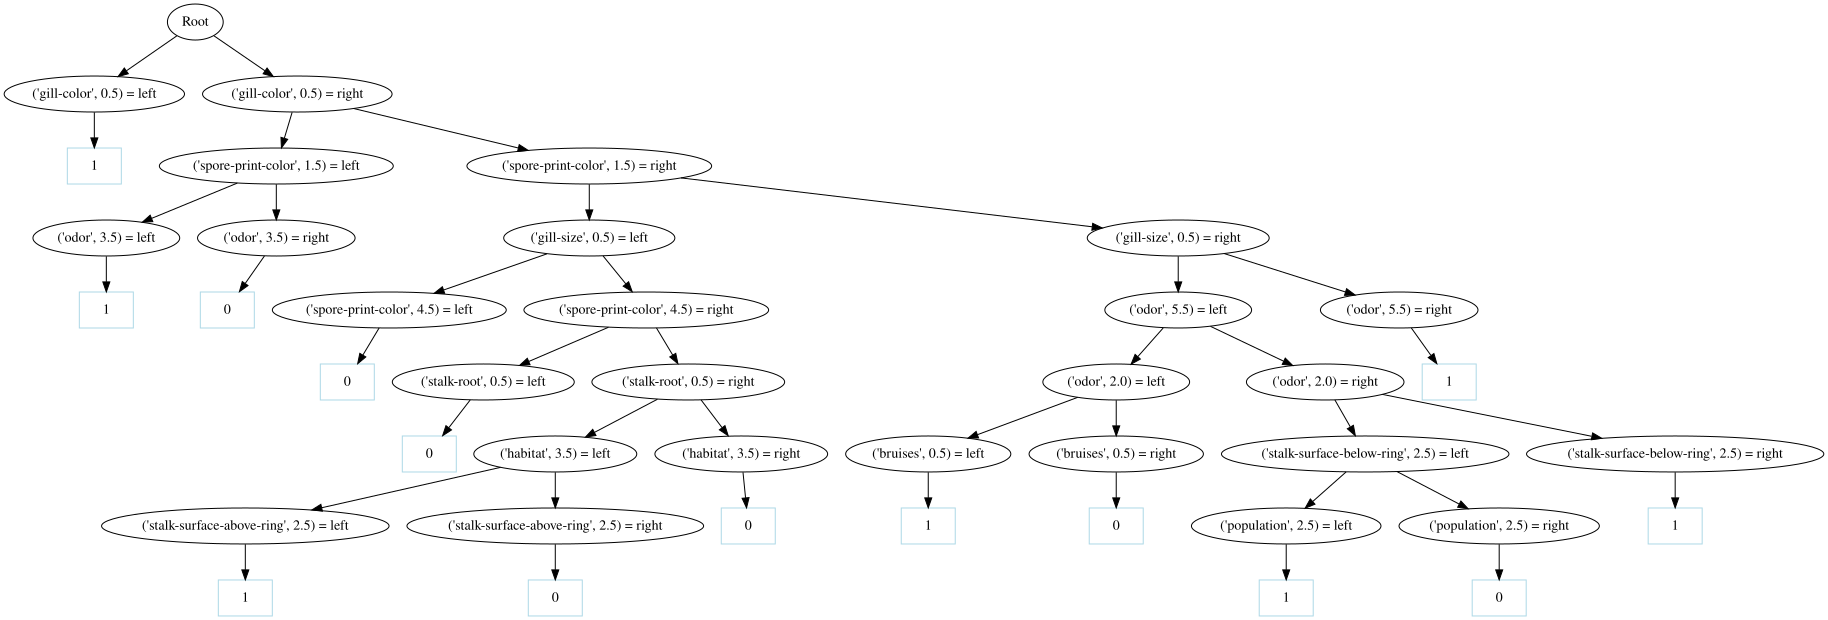

In [46]:
dot = visualize_tree(tree)
dot.render(format="png")
dot


In [58]:
# Cell 3: Hyperparameter tuning (max_depth analysis)
depths = [3, 5, 7, 10, None]
results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)
    
    results.append({
        "max_depth": d,
        "train_acc": accuracy_score(y_train, y_train_pred),
        "val_acc": accuracy_score(y_val, y_val_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "val_f1": f1_score(y_val, y_val_pred)
    })

df_results = pd.DataFrame(results)
df_results


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,max_depth,train_acc,val_acc,train_f1,val_f1
0,3.0,0.957088,0.966366,0.956162,0.965459
1,5.0,0.977313,0.986874,0.976668,0.986509
2,7.0,1.000000,1.000000,1.000000,1.000000
3,10.0,1.000000,1.000000,1.000000,1.000000
4,NaN,1.000000,1.000000,1.000000,1.000000


In [60]:
# Cell 4: Performance metrics (best depth)
best_depth = int(df_results.iloc[df_results["val_acc"].idxmax()]["max_depth"])
clf_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
clf_best.fit(X_train, y_train)

y_val_pred = clf_best.predict(X_val)

print("Classification Report:\n", classification_report(y_val, y_val_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       631
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



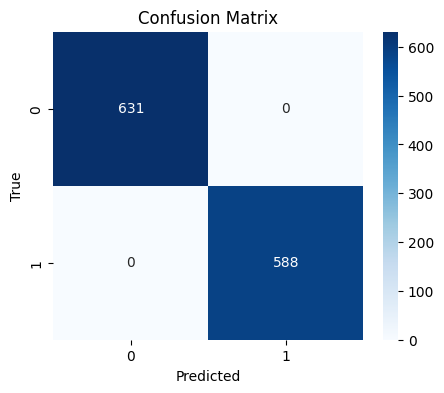

In [61]:
# Cell 5: Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


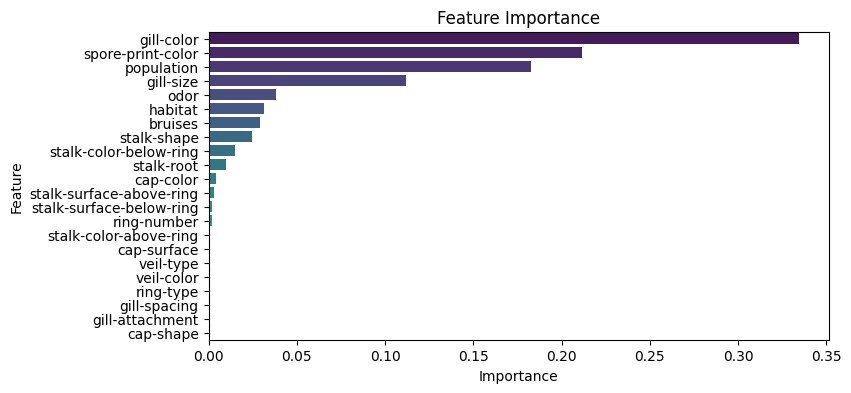

,Feature,Importance
8,gill-color,0.334466
19,spore-print-color,0.211654
20,population,0.182762
7,gill-size,0.111578
4,odor,0.038310
21,habitat,0.031148
3,bruises,0.029327
9,stalk-shape,0.024418
14,stalk-color-below-ring,0.014828
10,stalk-root,0.009695


In [62]:
# Cell 6: Feature Importance
importances = clf_best.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Feature Importance")
plt.show()

feat_imp


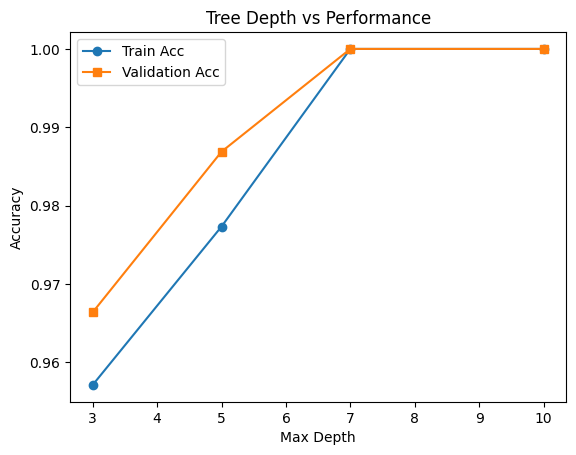

In [63]:
# Cell 7: Tree Complexity vs Performance
plt.plot(df_results["max_depth"], df_results["train_acc"], marker="o", label="Train Acc")
plt.plot(df_results["max_depth"], df_results["val_acc"], marker="s", label="Validation Acc")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Tree Depth vs Performance")
plt.legend()
plt.show()


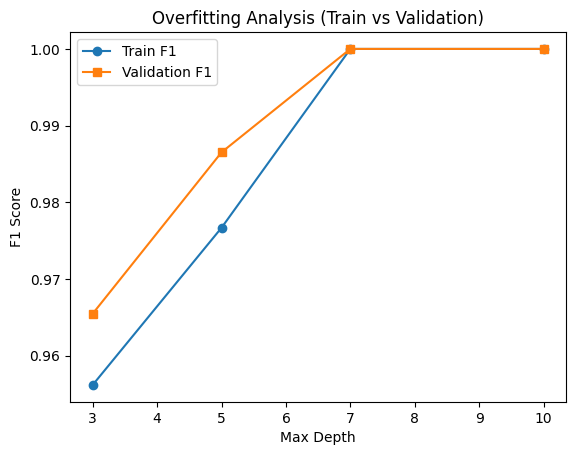

In [64]:
# Cell 8: Overfitting Analysis
plt.plot(df_results["max_depth"], df_results["train_f1"], marker="o", label="Train F1")
plt.plot(df_results["max_depth"], df_results["val_f1"], marker="s", label="Validation F1")
plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Overfitting Analysis (Train vs Validation)")
plt.legend()
plt.show()


In [68]:
def predict_one(tree, x):
    if not isinstance(tree, dict):
        return tree  # just return encoded label
    (feature, threshold), children = next(iter(tree.items()))
    value = x[feature]
    if value <= threshold:
        return predict_one(children['left'], x)
    else:
        return predict_one(children['right'], x)


In [69]:
# =========================
# Cell: Helper functions
# =========================
def predict(tree, X):
    """Predict for a whole dataset."""
    return [predict_one(tree, x) for _, x in X.iterrows()]

def accuracy(tree, X, y):
    preds = predict(tree, X)
    return np.mean(preds == y)


In [70]:
# =========================
# Cell: Reduced Error Post-Pruning
# =========================
def majority_class(y):
    """Return majority class in labels y."""
    return y.mode()[0]

def prune(tree, X_val, y_val):
    """Post-prune the decision tree using a validation set."""
    # If it's a leaf → nothing to prune
    if not isinstance(tree, dict):
        return tree

    # Extract feature, threshold, and children
    (feature, threshold), children = next(iter(tree.items()))
    left_subtree, right_subtree = children['left'], children['right']

    # Split validation data according to this node's split
    left_mask = X_val[feature] <= threshold
    right_mask = X_val[feature] > threshold

    # Recursively prune children
    pruned_left = prune(left_subtree, X_val[left_mask], y_val[left_mask])
    pruned_right = prune(right_subtree, X_val[right_mask], y_val[right_mask])

    # Update subtree after pruning children
    pruned_tree = {(feature, threshold): {'left': pruned_left, 'right': pruned_right}}

    # Check accuracy before pruning this node
    acc_before = accuracy(pruned_tree, X_val, y_val)

    # Check accuracy if we prune this node into a leaf
    leaf = majority_class(y_val)
    acc_after = accuracy(leaf, X_val, y_val)

    # If pruning doesn't hurt (or improves), replace subtree with leaf
    if acc_after >= acc_before:
        return leaf
    else:
        return pruned_tree


In [76]:
# =========================
# Cell: Train + Post-Prune
# =========================
# Train full tree (deep)
tree_model = DecisionTree(max_depth= None, min_samples_split=2)
full_tree = tree_model.fit(X_train, y_train)

print("Before Pruning:", accuracy(full_tree, X_val, y_val))

# Apply post-pruning using validation set
pruned_tree = prune(full_tree, X_val, y_val)

print("After Pruning:", accuracy(pruned_tree, X_val, y_val))


Before Pruning: 1.0
After Pruning: 1.0
